# 🧐 Test

In [3]:
# Test on a ustpo reaction WITHOUT atom mapping

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("sagawa/ReactionT5v2-forward", return_tensors="pt")
model = AutoModelForSeq2SeqLM.from_pretrained("sagawa/ReactionT5v2-forward")

inp = tokenizer('CC(=O)O.Cc1ccccc1O.O.O=[N+]([O-])OREAGENT: ', return_tensors='pt')
output = model.generate(**inp, num_beams=1, num_return_sequences=1, return_dict_in_generate=True, output_scores=True)
output = tokenizer.decode(output['sequences'][0], skip_special_tokens=True).replace(' ', '').rstrip('.')
output # True product Cc1cccc([N+](=O)[O-])c1O

/Users/e.mendoza/miniconda3/envs/reactionT5/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'Cc1cccc([N+](=O)[O-])c1O'

# Check the total of layers in the mode

In [4]:
from transformers import AutoModelForSeq2SeqLM

print(model.config.num_layers)  # This works for some models. Typically 12 for base

12


In [5]:
print("Encoder layers:", model.config.num_layers)  # typically 12 for base
print("Decoder layers:", model.config.num_decoder_layers)  # same by default

Encoder layers: 12
Decoder layers: 12


In [6]:
print(model.config.d_model)
print(model.config.num_heads)  

768
12


`d_model` refers to the dimensionality of the hidden representations — the size of the vectors that pass between layers.

You can think of it as:

🧩 Each token in the input/output is represented as a vector of length `d_model`.

A larger d_model means:

* More capacity to represent complex patterns

* But also more computation and memory usage

If `d_model` =  768, and e.g. and an iput text of 20 tokens, then the encoder input would be a matrix of shape: `(20 tokens, 512 features)`

# 1️⃣ Prediction Example

In [7]:
from rdkit import Chem
# Same example as in dgllife
dgllife_react = '[CH2:15]([CH:16]([CH3:17])[CH3:18])[Mg+:19].[CH2:20]1[O:21][CH2:22][CH2:23][CH2:24]1.[Cl-:14].[OH:1][c:2]1[n:3][cH:4][c:5]([C:6](=[O:7])[N:8]([O:9][CH3:10])[CH3:11])[cH:12][cH:13]1' 

# Remove atom mapping
mol = Chem.MolFromSmiles(dgllife_react)
if mol:
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)  # Remove atom mapping
    smi= Chem.MolToSmiles(mol)
smi

'C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]'

In [8]:
# Predict with ReactionT5

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("sagawa/ReactionT5v2-forward", return_tensors="pt")
model = AutoModelForSeq2SeqLM.from_pretrained("sagawa/ReactionT5v2-forward")

inp = tokenizer('C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT: ', return_tensors='pt')
output = model.generate(**inp, num_beams=1, num_return_sequences=1, return_dict_in_generate=True, output_scores=True)
print(output)
print(output.keys())
output = tokenizer.decode(output['sequences'][0], skip_special_tokens=True).replace(' ', '').rstrip('.')
output # True product CC(C)CC(=O)c1ccc(O)nc1

GenerateEncoderDecoderOutput(sequences=tensor([[ 0, 26,  6,  3,  5,  3,  3,  6, 15,  9,  5,  4,  7, 19,  6,  9,  5, 16,
          4,  7,  1]]), scores=(tensor([[-7.3039e+01, -4.0736e-01, -2.1879e+01,  7.2806e+00,  1.3590e-03,
          1.6234e+00,  3.7600e+00, -1.9041e+00, -4.1611e+00,  2.1458e+00,
         -9.3290e+00, -4.4044e+00, -6.5729e+00, -4.6445e+00, -2.0477e+00,
          2.1643e+00, -5.8443e+00, -5.6670e+00, -9.1145e+00, -3.3181e+00,
         -1.2313e+01, -4.2277e+00,  3.3540e+01, -3.0060e+00, -7.2998e+01,
          9.7333e+00,  5.5425e+01, -7.3004e+01,  2.2152e+00, -5.9814e+00,
         -4.0739e+00, -8.0713e+00,  3.6454e+01, -1.3840e+01, -1.8036e+01,
         -7.2947e+01,  3.3102e+00, -7.2938e+01, -4.0841e+00, -5.9386e+00,
         -6.7531e+00, -9.1739e+00, -6.4879e+00, -1.2249e+01, -7.2993e+01,
          1.5492e+01, -7.2907e+01,  1.8616e+01, -1.4227e+01, -7.2943e+01,
         -7.2773e+01, -7.8733e+00,  2.3501e+01, -8.8875e+00, -1.1601e+01,
          2.0215e+01, -8.6642e+00,

'CC(C)CC(=O)c1ccc(O)nc1'

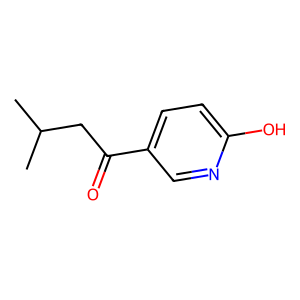

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw

# Define the SMILES string
smiles = 'CC(C)CC(=O)c1ccc(O)nc1'

# Convert SMILES to RDKit Mol object
mol = Chem.MolFromSmiles(smiles)

# Draw the molecule
img = Draw.MolToImage(mol)

# Display the image
display(img)

In [2]:
# Save as pdf

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
import cairosvg

def molecule_to_pdf(mol, file_name, width=300, height=300):
    """Save molecule structure as PDF."""

    full_path = f"{file_name}.pdf"

    # Prepare the drawer
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
    drawer.FinishDrawing()

    # Convert SVG to PDF
    svg = drawer.GetDrawingText()
    cairosvg.svg2pdf(bytestring=svg.encode(), write_to=full_path)

# SMILES string
smiles = "CC(C)CC(=O)c1ccc(O)nc1"

# Convert SMARTS → SMILES → Mol (removes query/dotted bonds)
# smiles = Chem.MolToSmiles(Chem.MolFromSmarts(smarts))
mol = Chem.MolFromSmiles(smiles)

# Generate 2D coordinates
AllChem.Compute2DCoords(mol)

# Export to PDF
molecule_to_pdf(mol, "pred_res")


#  2️⃣ Extract the input_ids directly from the tokenizer's output

In [22]:
# Predict with ReactionT5
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("sagawa/ReactionT5v2-forward", return_tensors="pt")
model = AutoModelForSeq2SeqLM.from_pretrained("sagawa/ReactionT5v2-forward")

inp = tokenizer('C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT: ', return_tensors='pt')

# Extract input_ids
"""
inp is a dictionary containing:
- 'input_ids': tensor of token IDs
- 'attention_mask': tensor showing which tokens should be attended to (1 = real token, 0 = padding)
"""

input_ids = inp['input_ids']
print(input_ids)


tensor([[ 22,   7,  82,   7, 221,  26,   6,   3,   5,   3,  11, 241,  25,  18,
          10, 221,  32,  12,   6,   3,   5,   3,   6,  15,   9,   5,   4,   7,
          19,   6,   9,   5,  16,   4,   7, 221,  25,  11,  36,  25,  23,  10,
         267,  25,   1]])


In [23]:
inp

{'input_ids': tensor([[ 22,   7,  82,   7, 221,  26,   6,   3,   5,   3,  11, 241,  25,  18,
          10, 221,  32,  12,   6,   3,   5,   3,   6,  15,   9,   5,   4,   7,
          19,   6,   9,   5,  16,   4,   7, 221,  25,  11,  36,  25,  23,  10,
         267,  25,   1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [24]:
# Call the original SMILES + reagent string by decoding the input SMILES back from the tokens
decoded_input = tokenizer.decode(input_ids[0], skip_special_tokens=True)
print(decoded_input)

C1CCOC1. CC(C)C[Mg +]. CON(C)C(=O)c1ccc(O)nc1. [Cl -] 


In [26]:
# Create decoder_input_ids
decoder_input_ids = model.prepare_decoder_input_ids_from_labels(input_ids)

# Forward pass
outputs = model(
    input_ids=input_ids,
    decoder_input_ids=decoder_input_ids,
    output_attentions=True,
    return_dict=True
)

print(outputs)

Seq2SeqLMOutput(loss=None, logits=tensor([[[-73.0386,  -0.4074, -21.8794,  ...,  -2.5760,  -4.2047,  -4.2035],
         [-56.2556,   8.3872,  -7.8098,  ...,  -2.4848,  -4.5632,  -4.5637],
         [-28.9158,   4.3395,  -3.6548,  ...,  -2.0709,  -4.5814,  -4.5800],
         ...,
         [-35.7001,  48.8045, -15.6957,  ...,  -6.7278,  -5.6763,  -5.6817],
         [-36.7168,  28.8357,  -6.8174,  ...,  -5.4045,  -4.8236,  -4.8252],
         [-37.3111,  15.8373,  -9.4414,  ...,  -3.2461,  -4.7721,  -4.7722]]],
       grad_fn=<UnsafeViewBackward0>), past_key_values=((tensor([[[[-3.9601e-02, -7.2390e-02, -5.8521e-02,  ...,  5.2022e-02,
            4.1675e-02,  4.0936e-02],
          [ 2.9449e-02,  1.0025e-01,  5.4636e-02,  ...,  4.4804e-02,
            6.6244e-02,  2.2922e-01],
          [ 3.9280e-02,  1.3142e-01,  1.2886e-01,  ..., -1.9232e-02,
            3.4474e-02,  5.7855e-02],
          ...,
          [-8.2547e-02,  4.4958e-02, -1.5172e-02,  ..., -1.7994e-02,
            5.3348e-03,  3

# 3️⃣ Get the average attention weights of tokens and filter those tokens with highest attention weights
This is for the analisys of the reaction center or "reaction site"

In [27]:
# Run the prediction again

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("sagawa/ReactionT5v2-forward", return_tensors="pt")
model = AutoModelForSeq2SeqLM.from_pretrained("sagawa/ReactionT5v2-forward")

inp = tokenizer('REACTANT:COC(=O)C1=CCCN(C)C1.O.[Al+3].[H-].[Li+].[Na+].[OH-]REAGENT:C1CCOC1', return_tensors='pt')
output = model.generate(**inp, num_beams=1, num_return_sequences=1, return_dict_in_generate=True, output_attentions=True)
print(output.keys())  # odict_keys(['sequences', 'encoder_attentions', 'decoder_attentions', 'cross_attentions', 'past_key_values'])

odict_keys(['sequences', 'encoder_attentions', 'decoder_attentions', 'cross_attentions', 'past_key_values'])


In [28]:
# The predicted product
print(output) # Dict
print(tokenizer.decode(output['sequences'][0], skip_special_tokens=True).replace(' ', '').rstrip('.')) # Pred product

GenerateEncoderDecoderOutput(sequences=tensor([[ 0, 47,  7, 29, 15,  3,  6,  3,  9,  5,  3,  7,  1]]), scores=None, logits=None, encoder_attentions=(tensor([[[[1.6251e-04, 9.9595e-07, 1.1424e-06,  ..., 1.4157e-02,
           2.0559e-02, 1.7605e-02],
          [9.9995e-01, 1.9396e-09, 3.0706e-11,  ..., 1.4845e-07,
           2.4023e-07, 7.6948e-07],
          [6.5605e-01, 3.4394e-01, 1.6538e-09,  ..., 3.5910e-07,
           2.3840e-07, 1.5697e-07],
          ...,
          [3.9799e-06, 7.7035e-07, 2.0240e-06,  ..., 1.9432e-11,
           2.1149e-13, 5.7980e-13],
          [4.5252e-06, 2.6304e-05, 6.5570e-06,  ..., 7.3090e-02,
           5.7004e-10, 1.5940e-12],
          [6.9818e-07, 4.4839e-07, 7.4076e-07,  ..., 5.6166e-03,
           1.8673e-03, 1.9638e-11]],

         [[9.4016e-11, 6.2739e-11, 5.6225e-09,  ..., 4.2774e-02,
           4.2395e-02, 5.7900e-02],
          [2.4524e-06, 1.0288e-10, 5.7007e-11,  ..., 5.6346e-02,
           4.6669e-02, 5.4787e-02],
          [8.0469e-01, 3.4

In [29]:
# Access the cross-attention weights

# The output is a tensor with the following dimensions:
# [batch_size, num_heads, sequence_length_decoder, sequence_length_encoder]

# batch_size: The number of input sequences processed in parallel. In your example, it's implied to be 1.
# num_heads: The number of attention heads in the decoder's cross-attention layers. Each head focuses on different aspects of the input.
# sequence_length_decoder: The length of the decoder's output sequence (the generated text).
# sequence_length_encoder: The length of the encoder's input sequence.

cross_attentions = output.cross_attentions  # Tuple of tensors
cross_attentions

((tensor([[[[5.0186e-02, 7.1570e-04, 3.4806e-04, 2.7003e-04, 2.5240e-04,
             2.1863e-04, 1.9587e-04, 1.3752e-04, 1.2122e-04, 1.1373e-04,
             4.9062e-04, 4.3715e-04, 2.5966e-04, 2.5056e-04, 3.6730e-04,
             7.9078e-02, 2.5388e-03, 7.2998e-02, 3.9493e-02, 3.1979e-02,
             1.0103e-04, 7.7724e-05, 8.5220e-05, 8.2157e-05, 8.2945e-05,
             6.6491e-02, 3.3936e-02, 2.7601e-02, 6.5162e-05, 5.9386e-05,
             5.8109e-05, 6.2843e-02, 3.1927e-02, 2.5918e-02, 2.3865e-02,
             8.9580e-05, 1.0813e-04, 1.1904e-04, 6.3836e-02, 3.1575e-02,
             2.5317e-02, 2.2171e-02, 2.7315e-02, 5.2036e-04, 3.8685e-04,
             6.8727e-02, 3.2525e-02, 2.7075e-02, 2.4294e-04, 1.8586e-04,
             2.3197e-04, 1.8436e-04, 5.3814e-02, 5.2454e-03, 3.9663e-02,
             2.2655e-04, 2.8017e-04, 4.6515e-02]],
  
           [[2.3484e-08, 8.6690e-08, 2.4713e-07, 3.1129e-07, 2.9525e-07,
             3.8623e-07, 3.8702e-07, 4.3816e-07, 2.3085e-07, 2.4121e-0

In [30]:
# Aggregate the attention weights (example: average across heads and layers)
# NOTE This is a simplified approach; more refined aggregation may be needed.

import torch

# Process the cross-attention weights
aggregated_attentions = []
for layer in cross_attentions:
    # Ensure layer is a tensor
    if isinstance(layer, tuple):
        layer = layer[0]  # If it's a tuple, take the first element (the tensor)

    # Average across attention heads (dim=1)
    layer_avg_heads = torch.mean(layer, dim=1)
    aggregated_attentions.append(layer_avg_heads)

# Stack the aggregated attention tensors
aggregated_attentions = torch.stack(aggregated_attentions)

# Average across layers (dim=0)
aggregated_attentions = torch.mean(aggregated_attentions, dim=0)
aggregated_attentions

tensor([[[0.0499, 0.0054, 0.0052, 0.0046, 0.0041, 0.0046, 0.0046, 0.0032,
          0.0039, 0.0036, 0.0047, 0.0044, 0.0043, 0.0052, 0.0051, 0.0702,
          0.0105, 0.0647, 0.0334, 0.0276, 0.0027, 0.0027, 0.0028, 0.0029,
          0.0029, 0.0577, 0.0289, 0.0243, 0.0023, 0.0023, 0.0023, 0.0555,
          0.0276, 0.0231, 0.0209, 0.0018, 0.0019, 0.0018, 0.0564, 0.0274,
          0.0227, 0.0202, 0.0238, 0.0013, 0.0012, 0.0601, 0.0280, 0.0237,
          0.0020, 0.0020, 0.0020, 0.0019, 0.0476, 0.0081, 0.0357, 0.0017,
          0.0019, 0.0484]]])

In [31]:
# Get the last generated token attention.
last_token_attentions = aggregated_attentions[0, -1, :]
last_token_attentions

tensor([0.0499, 0.0054, 0.0052, 0.0046, 0.0041, 0.0046, 0.0046, 0.0032, 0.0039,
        0.0036, 0.0047, 0.0044, 0.0043, 0.0052, 0.0051, 0.0702, 0.0105, 0.0647,
        0.0334, 0.0276, 0.0027, 0.0027, 0.0028, 0.0029, 0.0029, 0.0577, 0.0289,
        0.0243, 0.0023, 0.0023, 0.0023, 0.0555, 0.0276, 0.0231, 0.0209, 0.0018,
        0.0019, 0.0018, 0.0564, 0.0274, 0.0227, 0.0202, 0.0238, 0.0013, 0.0012,
        0.0601, 0.0280, 0.0237, 0.0020, 0.0020, 0.0020, 0.0019, 0.0476, 0.0081,
        0.0357, 0.0017, 0.0019, 0.0484])

In [32]:
# Get the top attention values and their indices.
top_attention_values, top_attention_indices = torch.topk(last_token_attentions, k=10)

# Tokenize the input
input_ids = tokenizer.encode('REACTANT:COC(=O)C1=CCCN(C)C1.O.[Al+3].[H-].[Li+].[Na+].[OH-]REAGENT:C1CCOC1', return_tensors="pt")

# Decode the input ids to get the tokens.
input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
input_tokens

['REACTANT:',
 '▁COC',
 '(',
 '=',
 'O',
 ')',
 'C',
 '1',
 '=',
 'CCCN',
 '(',
 'C',
 ')',
 'C',
 '1',
 '.',
 '▁O',
 '.',
 '▁',
 '[',
 'Al',
 '▁',
 '+',
 '3',
 ']',
 '.',
 '▁',
 '[',
 'H',
 '-',
 ']',
 '.',
 '▁',
 '[',
 'Li',
 '▁',
 '+',
 ']',
 '.',
 '▁',
 '[',
 'Na',
 '▁',
 '+',
 ']',
 '.',
 '▁',
 '[',
 'O',
 'H',
 '-',
 ']',
 'REAGENT:',
 '▁C',
 '1',
 'CCOC',
 '1',
 '</s>']

In [33]:
# Print the top attended to input tokens.
for i in range(len(top_attention_indices)):
    print(f"Token: '{input_tokens[top_attention_indices[i]]}', Attention: {top_attention_values[i].item()}")

# Decode the generated output.
generated_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

print(f"Input Text: {'REACTANT:COC(=O)C1=CCCN(C)C1.O.[Al+3].[H-].[Li+].[Na+].[OH-]REAGENT:C1CCOC1'}")
print(f"Generated Text: {generated_text}") # Pred product

Token: '.', Attention: 0.07019191235303879
Token: '.', Attention: 0.06472402811050415
Token: '.', Attention: 0.06009926274418831
Token: '.', Attention: 0.05774101987481117
Token: '.', Attention: 0.0564456470310688
Token: '.', Attention: 0.055494457483291626
Token: 'REACTANT:', Attention: 0.049925222992897034
Token: '</s>', Attention: 0.04840483143925667
Token: 'REAGENT:', Attention: 0.047585178166627884
Token: '1', Attention: 0.0357254222035408
Input Text: REACTANT:COC(=O)C1=CCCN(C)C1.O.[Al+3].[H-].[Li+].[Na+].[OH-]REAGENT:C1CCOC1
Generated Text: CN1CCC=C(CO)C1


# NOTE on Why the dots (.) ended up with the highest attention weights:

1. SentencePiece Tokenization:

* T5 uses SentencePiece tokenization, which breaks down text into subword units.
* his tokenization method treats punctuation marks like dots (.) as individual tokens.
* In your input string, the dots are used to separate different parts of the chemical formula-like input.
* Because the model processes each dot as a distinct token, they are treated as individual focal points during attention.

2. Specialized Input:

* Your input string is not natural language; it's a specialized representation of chemical structures and components.
* The model has likely learned to pay close attention to the dots because they serve as crucial delimiters in this type of data.
* The dots are very important to understand the structure of the input. In this case, they separate the different chemical components.

3. Contextual Importance:

* The dots are not just random punctuation; they convey structural information.
* The model might have learned that when it encounters dots in this context, it needs to pay close attention to them to understand the relationships between the surrounding tokens.

4. Token Frequency and Importance

* The model may have learned that these tokens are very important because they are used to separate the chemical components.
* The model may have learned that the other characters are less important, and are more likely to be part of a larger token.

5. Model's Internal Representations:

* Ultimately, the attention weights reflect the model's internal representations and how it has learned to process the data.
* It's possible that the model has developed a strong bias toward the dots because they are consistently relevant in this type of input.

## Add a filter

In [34]:
# Get the top attention values and their indices.
top_attention_values, top_attention_indices = torch.topk(
    last_token_attentions, k=50  # Increase k to get more options
)

In [ ]:
# Decode the input ids to get the tokens.
input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Print the top attended to input tokens (excluding dots)
important_tokens = []  # Initialize as an empty list
important_attention = [] # Initialize as an empty list.
for i in range(len(top_attention_indices)):
    token = input_tokens[top_attention_indices[i]]
    if token != ".":
        important_tokens.append(token)
        important_attention.append(top_attention_values[i].item())

#Print the top tokens that are not dots.
for i in range(len(important_tokens[:50])): #Print the top 50
     print(f"Token: '{important_tokens[i]}', Attention: {important_attention[i]}")

# Decode the generated output.
generated_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

print(f"Input Text: {'REACTANT:COC(=O)C1=CCCN(C)C1.O.[Al+3].[H-].[Li+].[Na+].[OH-]REAGENT:C1CCOC1'}")
print(f"Generated Text: {generated_text}")

Token: 'REACTANT:', Attention: 0.049925222992897034
Token: '</s>', Attention: 0.04840483143925667
Token: 'REAGENT:', Attention: 0.047585178166627884
Token: '1', Attention: 0.0357254222035408
Token: '▁', Attention: 0.033445093780756
Token: '▁', Attention: 0.028916241601109505
Token: '▁', Attention: 0.027987360954284668
Token: '▁', Attention: 0.02764044888317585
Token: '[', Attention: 0.02759363502264023
Token: '▁', Attention: 0.02738824300467968
Token: '[', Attention: 0.02430027723312378
Token: '▁', Attention: 0.02382597140967846
Token: '[', Attention: 0.02371060661971569
Token: '[', Attention: 0.023080741986632347
Token: '[', Attention: 0.022715101018548012
Token: 'Li', Attention: 0.02094467543065548
Token: 'Na', Attention: 0.02019806206226349
Token: '▁O', Attention: 0.010525356978178024
Token: '▁C', Attention: 0.008080190978944302
Token: '▁COC', Attention: 0.005421854555606842
Token: '(', Attention: 0.005206138361245394
Token: 'C', Attention: 0.005201812367886305
Token: '1', Attention

# 4️⃣ Run another example (milab article example)

In [1]:
#C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("sagawa/ReactionT5v2-forward", return_tensors="pt")
model = AutoModelForSeq2SeqLM.from_pretrained("sagawa/ReactionT5v2-forward")

inp = tokenizer('REACTANT:C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT:', return_tensors='pt')
output = model.generate(**inp, num_beams=1, num_return_sequences=1, return_dict_in_generate=True, output_attentions=True)
print(output.keys())  # odict_keys(['sequences', 'encoder_attentions', 'decoder_attentions', 'cross_attentions', 'past_key_values'])

/Users/e.mendoza/miniconda3/envs/reactionT5/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


odict_keys(['sequences', 'encoder_attentions', 'decoder_attentions', 'cross_attentions', 'past_key_values'])


In [2]:
# The predicted product
print(output) # Dict
print(tokenizer.decode(output['sequences'][0], skip_special_tokens=True).replace(' ', '').rstrip('.')) # Pred product

GenerateEncoderDecoderOutput(sequences=tensor([[ 0, 26,  6,  3,  5,  3,  3,  6, 15,  9,  5,  4,  7, 19,  6,  9,  5, 16,
          4,  7,  1]]), scores=None, logits=None, encoder_attentions=(tensor([[[[2.7032e-04, 1.7145e-06, 1.7721e-06,  ..., 1.7601e-02,
           1.4640e-01, 9.6426e-03],
          [9.9998e-01, 4.2969e-09, 3.1649e-11,  ..., 7.2213e-07,
           3.8808e-07, 2.7333e-07],
          [5.3412e-01, 4.6588e-01, 3.7372e-09,  ..., 1.5433e-08,
           1.5763e-08, 4.8586e-08],
          ...,
          [3.6612e-05, 1.2593e-04, 6.0793e-05,  ..., 1.7378e-10,
           3.3217e-12, 1.8815e-12],
          [4.2800e-05, 2.9761e-05, 2.4408e-05,  ..., 2.6901e-02,
           2.6515e-10, 2.2109e-12],
          [7.5992e-06, 4.5511e-06, 6.2538e-06,  ..., 7.4497e-02,
           7.3914e-01, 5.1627e-11]],

         [[2.0350e-10, 1.0946e-10, 1.2190e-08,  ..., 6.5619e-02,
           9.2883e-02, 8.5093e-02],
          [3.6580e-06, 1.7739e-10, 1.3080e-10,  ..., 6.9358e-02,
           5.7511e-02

In [3]:
# Get generated token IDs (first and only sequence)
output_ids = output["sequences"][0]

# Convert IDs to tokens
output_tokens = tokenizer.convert_ids_to_tokens(output_ids)

# Optional: decode into string
decoded_output = tokenizer.decode(output_ids, skip_special_tokens=True)

# Print result
print("Output Tokens:", output_tokens)
print("Decoded Output:", decoded_output)


Output Tokens: ['<pad>', '▁CC', '(', 'C', ')', 'C', 'C', '(', '=', 'O', ')', 'c', '1', 'ccc', '(', 'O', ')', 'n', 'c', '1', '</s>']
Decoded Output: CC(C)CC(=O)c1ccc(O)nc1


In [4]:
cross_attentions = output.cross_attentions  # Tuple of tensors
cross_attentions

((tensor([[[[8.8295e-02, 5.7125e-03, 8.7772e-02, 2.0552e-03, 1.7023e-03,
             1.2809e-01, 2.7464e-04, 1.8945e-04, 1.2930e-04, 1.1634e-04,
             1.9331e-04, 2.8934e-04, 1.3001e-03, 1.5805e-03, 1.6451e-03,
             1.7211e-03, 1.3942e-01, 1.6919e-03, 9.4848e-04, 1.1329e-03,
             7.5946e-04, 8.4290e-04, 4.3348e-04, 4.3333e-04, 5.0238e-04,
             5.3216e-04, 7.4847e-04, 9.4883e-04, 7.9438e-04, 1.3896e-03,
             9.4090e-04, 2.2985e-04, 2.1059e-04, 6.2065e-04, 1.4370e-03,
             1.3963e-03, 1.4443e-01, 8.3252e-02, 6.4541e-02, 8.8674e-04,
             4.9557e-04, 4.6361e-04, 6.7544e-04, 1.3969e-01, 8.9082e-02]],
  
           [[7.1794e-05, 4.9642e-02, 3.2288e-04, 4.6305e-01, 4.4533e-01,
             6.2029e-05, 3.4077e-04, 6.3741e-04, 1.0190e-03, 9.7422e-04,
             7.7178e-04, 2.0085e-03, 5.0760e-03, 3.4148e-03, 4.2680e-03,
             5.6115e-03, 6.0818e-05, 8.3747e-04, 1.1684e-03, 1.4345e-03,
             1.9855e-03, 7.0203e-04, 2.6575e-0

In [ ]:
## # Get attention weights of all the layers and average

# import torch

# # Process the cross-attention weights
# aggregated_attentions = []
# for layer in cross_attentions:
#     # Ensure layer is a tensor
#     if isinstance(layer, tuple):
#         layer = layer[0]  # If it's a tuple, take the first element (the tensor)

#     # Average across attention heads (dim=1)
#     layer_avg_heads = torch.mean(layer, dim=1)
#     aggregated_attentions.append(layer_avg_heads)

# # Stack the aggregated attention tensors
# aggregated_attentions = torch.stack(aggregated_attentions)

# # Average across layers (dim=0)
# aggregated_attentions = torch.mean(aggregated_attentions, dim=0)
# aggregated_attentions

tensor([[[0.0882, 0.0100, 0.0741, 0.0101, 0.0081, 0.1129, 0.0035, 0.0033,
          0.0034, 0.0030, 0.0039, 0.0036, 0.0028, 0.0025, 0.0027, 0.0026,
          0.1182, 0.0054, 0.0024, 0.0022, 0.0029, 0.0030, 0.0027, 0.0029,
          0.0031, 0.0032, 0.0041, 0.0041, 0.0043, 0.0046, 0.0044, 0.0029,
          0.0028, 0.0033, 0.0050, 0.0050, 0.1293, 0.0706, 0.0560, 0.0023,
          0.0021, 0.0024, 0.0026, 0.1247, 0.0886]]])

In [ ]:
# # Get the last generated token attention.
# last_token_attentions = aggregated_attentions[0, -1, :]
# last_token_attentions

tensor([0.0882, 0.0100, 0.0741, 0.0101, 0.0081, 0.1129, 0.0035, 0.0033, 0.0034,
        0.0030, 0.0039, 0.0036, 0.0028, 0.0025, 0.0027, 0.0026, 0.1182, 0.0054,
        0.0024, 0.0022, 0.0029, 0.0030, 0.0027, 0.0029, 0.0031, 0.0032, 0.0041,
        0.0041, 0.0043, 0.0046, 0.0044, 0.0029, 0.0028, 0.0033, 0.0050, 0.0050,
        0.1293, 0.0706, 0.0560, 0.0023, 0.0021, 0.0024, 0.0026, 0.1247, 0.0886])

In [5]:
# Get attention weights of last layer

import torch

# Get the last layer's cross-attention
last_layer = cross_attentions[-1]

# Ensure it's a tensor if it's a tuple
if isinstance(last_layer, tuple):
    last_layer = last_layer[0]

# Average across attention heads (dim=1), if needed
last_layer_avg_heads = torch.mean(last_layer, dim=1)

# aggregated_attentions = last_layer  # shape: [batch_size, num_heads, tgt_len, src_len] If you want per-head attention values (i.e. no averaging at all), just skip the torch.mean step:

# Result: attention from the last layer, averaged over heads
aggregated_attentions = last_layer_avg_heads

In [6]:
# Get the last generated token attention.
last_token_attentions = aggregated_attentions[0, -1, :]
last_token_attentions

tensor([0.0868, 0.0109, 0.0750, 0.0072, 0.0068, 0.1070, 0.0017, 0.0015, 0.0016,
        0.0019, 0.0024, 0.0027, 0.0035, 0.0030, 0.0033, 0.0035, 0.1113, 0.0058,
        0.0021, 0.0019, 0.0023, 0.0031, 0.0033, 0.0036, 0.0037, 0.0039, 0.0057,
        0.0076, 0.0092, 0.0108, 0.0106, 0.0046, 0.0043, 0.0058, 0.0082, 0.0086,
        0.1205, 0.0709, 0.0575, 0.0034, 0.0030, 0.0032, 0.0032, 0.1165, 0.0868])

In [7]:
# Get the top attention values and their indices.
top_attention_values, top_attention_indices = torch.topk(last_token_attentions, k=40)

# Tokenize the input
input_ids = tokenizer.encode('REACTANT:C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT:', return_tensors="pt")

# Decode the input ids to get the tokens.
input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
input_tokens

['REACTANT:',
 '▁C',
 '1',
 'CCOC',
 '1',
 '.',
 '▁CC',
 '(',
 'C',
 ')',
 'C',
 '[',
 'Mg',
 '▁',
 '+',
 ']',
 '.',
 '▁CO',
 'N',
 '(',
 'C',
 ')',
 'C',
 '(',
 '=',
 'O',
 ')',
 'c',
 '1',
 'ccc',
 '(',
 'O',
 ')',
 'n',
 'c',
 '1',
 '.',
 '▁',
 '[',
 'Cl',
 '▁',
 '-',
 ']',
 'REAGENT:',
 '</s>']

In [8]:
top_attention_indices

tensor([36, 43, 16,  5,  0, 44,  2, 37, 38,  1, 29, 30, 28, 35, 34, 27,  3,  4,
        33, 17, 26, 31, 32, 25, 24, 23, 12, 15, 39, 14, 22, 42, 41, 21, 13, 40,
        11, 10, 20, 18])

In [9]:
print(len(input_tokens), top_attention_indices)

45 tensor([36, 43, 16,  5,  0, 44,  2, 37, 38,  1, 29, 30, 28, 35, 34, 27,  3,  4,
        33, 17, 26, 31, 32, 25, 24, 23, 12, 15, 39, 14, 22, 42, 41, 21, 13, 40,
        11, 10, 20, 18])


In [10]:
# Print the top attended to input tokens.
for i in range(len(top_attention_indices)):
    print(f"Token: '{input_tokens[top_attention_indices[i]]}', Attention: {top_attention_values[i].item()}")

# Decode the generated output.
generated_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

print(f"Input Text: {'REACTANT:C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT:'}")
print(f"Generated Text: {generated_text}") # Pred product

Token: '.', Attention: 0.12049221247434616
Token: 'REAGENT:', Attention: 0.11652220040559769
Token: '.', Attention: 0.11131352186203003
Token: '.', Attention: 0.1069553792476654
Token: 'REACTANT:', Attention: 0.0867706909775734
Token: '</s>', Attention: 0.08675804734230042
Token: '1', Attention: 0.0749581828713417
Token: '▁', Attention: 0.07091189920902252
Token: '[', Attention: 0.0574931837618351
Token: '▁C', Attention: 0.010852638632059097
Token: 'ccc', Attention: 0.010787115432322025
Token: '(', Attention: 0.010596177540719509
Token: '1', Attention: 0.009186591021716595
Token: '1', Attention: 0.008638140745460987
Token: 'c', Attention: 0.008224972523748875
Token: 'c', Attention: 0.007627077400684357
Token: 'CCOC', Attention: 0.007220862898975611
Token: '1', Attention: 0.00682581914588809
Token: 'n', Attention: 0.005765391048043966
Token: '▁CO', Attention: 0.005757796112447977
Token: ')', Attention: 0.005707120057195425
Token: 'O', Attention: 0.004604121204465628
Token: ')', Attentio

## Filter out the dots and other useless characters

In [11]:
#C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]

# Decode the input ids to get the tokens.
input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Print the top attended to input tokens (excluding dots)
important_tokens = []  # Initialize as an empty list
important_attention = [] # Initialize as an empty list.
for i in range(len(top_attention_indices)):
    token = input_tokens[top_attention_indices[i]]
    if token != ".":
        important_tokens.append(token)
        important_attention.append(top_attention_values[i].item())

#Print the top tokens that are not dots.
for i in range(len(important_tokens[:100])): #Print the top 10
     print(f"Token: '{important_tokens[i]}', Attention: {important_attention[i]}")

# Decode the generated output.
generated_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

print(f"Input Text: {'REACTANT:C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT:'}")
print(f"Generated Text: {generated_text}")

Token: 'REAGENT:', Attention: 0.11652220040559769
Token: 'REACTANT:', Attention: 0.0867706909775734
Token: '</s>', Attention: 0.08675804734230042
Token: '1', Attention: 0.0749581828713417
Token: '▁', Attention: 0.07091189920902252
Token: '[', Attention: 0.0574931837618351
Token: '▁C', Attention: 0.010852638632059097
Token: 'ccc', Attention: 0.010787115432322025
Token: '(', Attention: 0.010596177540719509
Token: '1', Attention: 0.009186591021716595
Token: '1', Attention: 0.008638140745460987
Token: 'c', Attention: 0.008224972523748875
Token: 'c', Attention: 0.007627077400684357
Token: 'CCOC', Attention: 0.007220862898975611
Token: '1', Attention: 0.00682581914588809
Token: 'n', Attention: 0.005765391048043966
Token: '▁CO', Attention: 0.005757796112447977
Token: ')', Attention: 0.005707120057195425
Token: 'O', Attention: 0.004604121204465628
Token: ')', Attention: 0.0043433732353150845
Token: 'O', Attention: 0.0038633670192211866
Token: '=', Attention: 0.0037438981235027313
Token: '(', A

In [12]:
# Decode the input ids to get the tokens.
input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Print the top attended to input tokens (excluding dots and other specified characters)
important_tokens = []  # Initialize as an empty list
important_attention = [] # Initialize as an empty list.
char_to_filter = ['REAGENT:', 'REACTANT:', '▁', '[', ']', '.', '(', ')'] #added dot to the list
for i in range(len(top_attention_indices)):
    token = input_tokens[top_attention_indices[i]]
    if token not in char_to_filter:
        important_tokens.append(token)
        important_attention.append(top_attention_values[i].item())

#Print the top tokens that are not dots.
for i in range(len(important_tokens[:100])): #Print the top 100
     print(f"Token: '{important_tokens[i]}', Attention: {important_attention[i]}")

# Decode the generated output.
generated_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

print(f"Input Text: {'REACTANT:C1CCOC1.CC(C)C[Mg+].CON(C)C(=O)c1ccc(O)nc1.[Cl-]REAGENT:'}")
print(f"Generated Text: {generated_text}")

Token: '</s>', Attention: 0.08675804734230042
Token: '1', Attention: 0.0749581828713417
Token: '▁C', Attention: 0.010852638632059097
Token: 'ccc', Attention: 0.010787115432322025
Token: '1', Attention: 0.009186591021716595
Token: '1', Attention: 0.008638140745460987
Token: 'c', Attention: 0.008224972523748875
Token: 'c', Attention: 0.007627077400684357
Token: 'CCOC', Attention: 0.007220862898975611
Token: '1', Attention: 0.00682581914588809
Token: 'n', Attention: 0.005765391048043966
Token: '▁CO', Attention: 0.005757796112447977
Token: 'O', Attention: 0.004604121204465628
Token: 'O', Attention: 0.0038633670192211866
Token: '=', Attention: 0.0037438981235027313
Token: 'Mg', Attention: 0.0035211758222430944
Token: 'Cl', Attention: 0.003377495100721717
Token: '+', Attention: 0.003349429229274392
Token: 'C', Attention: 0.003336135996505618
Token: '-', Attention: 0.003158898325636983
Token: 'C', Attention: 0.0023625327739864588
Token: 'C', Attention: 0.0022665555588901043
Token: 'N', Attent

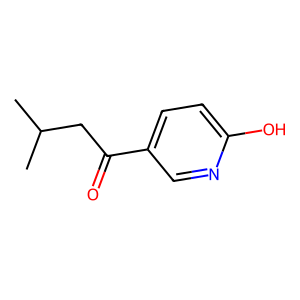

In [77]:
# Draw pred result # CC(C)CC(=O)c1ccc(O)nc1
from rdkit import Chem
from rdkit.Chem import Draw

# Define the SMILES string
smiles = 'CC(C)CC(=O)c1ccc(O)nc1' 

# Convert SMILES to RDKit Mol object
mol = Chem.MolFromSmiles(smiles)

# Draw the molecule
img = Draw.MolToImage(mol)

# Display the image
display(img)

# 5️⃣ Extra: Plot attention heatmaps for each head

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_heads(attn_tensor, source_tokens, target_tokens, figsize=(20, 8)):
    """
    attn_tensor: [1, num_heads, target_len, source_len]
    source_tokens: list of str, encoder input tokens
    target_tokens: list of str, decoder output tokens
    """
    num_heads = attn_tensor.shape[1]
    fig, axs = plt.subplots(1, num_heads, figsize=figsize)

    for head in range(num_heads):
        ax = axs[head] if num_heads > 1 else axs
        sns.heatmap(
            attn_tensor[0, head].detach().cpu().numpy(),
            xticklabels=source_tokens,
            yticklabels=target_tokens,
            cmap="viridis",
            ax=ax
        )
        ax.set_title(f'Head {head}')
        ax.set_xlabel("Source (Encoder) Tokens")
        ax.set_ylabel("Target (Decoder) Tokens")

    plt.tight_layout()
    plt.show()


In [ ]:
# Token: '▁C', Attention: 0.010852638632059097
# Token: 'ccc', Attention: 0.010787115432322025
# Token: '1', Attention: 0.009186591021716595
# Token: '1', Attention: 0.008638140745460987
# Token: 'c', Attention: 0.008224972523748875
# Token: 'c', Attention: 0.007627077400684357
# Token: 'CCOC', Attention: 0.007220862898975611
# Token: '1', Attention: 0.00682581914588809
# Token: 'n', Attention: 0.005765391048043966
# Token: '▁CO', Attention: 0.005757796112447977

In [14]:
last_layer.shape

torch.Size([1, 12, 1, 45])

In [15]:
input_tokens

['REACTANT:',
 '▁C',
 '1',
 'CCOC',
 '1',
 '.',
 '▁CC',
 '(',
 'C',
 ')',
 'C',
 '[',
 'Mg',
 '▁',
 '+',
 ']',
 '.',
 '▁CO',
 'N',
 '(',
 'C',
 ')',
 'C',
 '(',
 '=',
 'O',
 ')',
 'c',
 '1',
 'ccc',
 '(',
 'O',
 ')',
 'n',
 'c',
 '1',
 '.',
 '▁',
 '[',
 'Cl',
 '▁',
 '-',
 ']',
 'REAGENT:',
 '</s>']

In [16]:
output_tokens

['<pad>',
 '▁CC',
 '(',
 'C',
 ')',
 'C',
 'C',
 '(',
 '=',
 'O',
 ')',
 'c',
 '1',
 'ccc',
 '(',
 'O',
 ')',
 'n',
 'c',
 '1',
 '</s>']

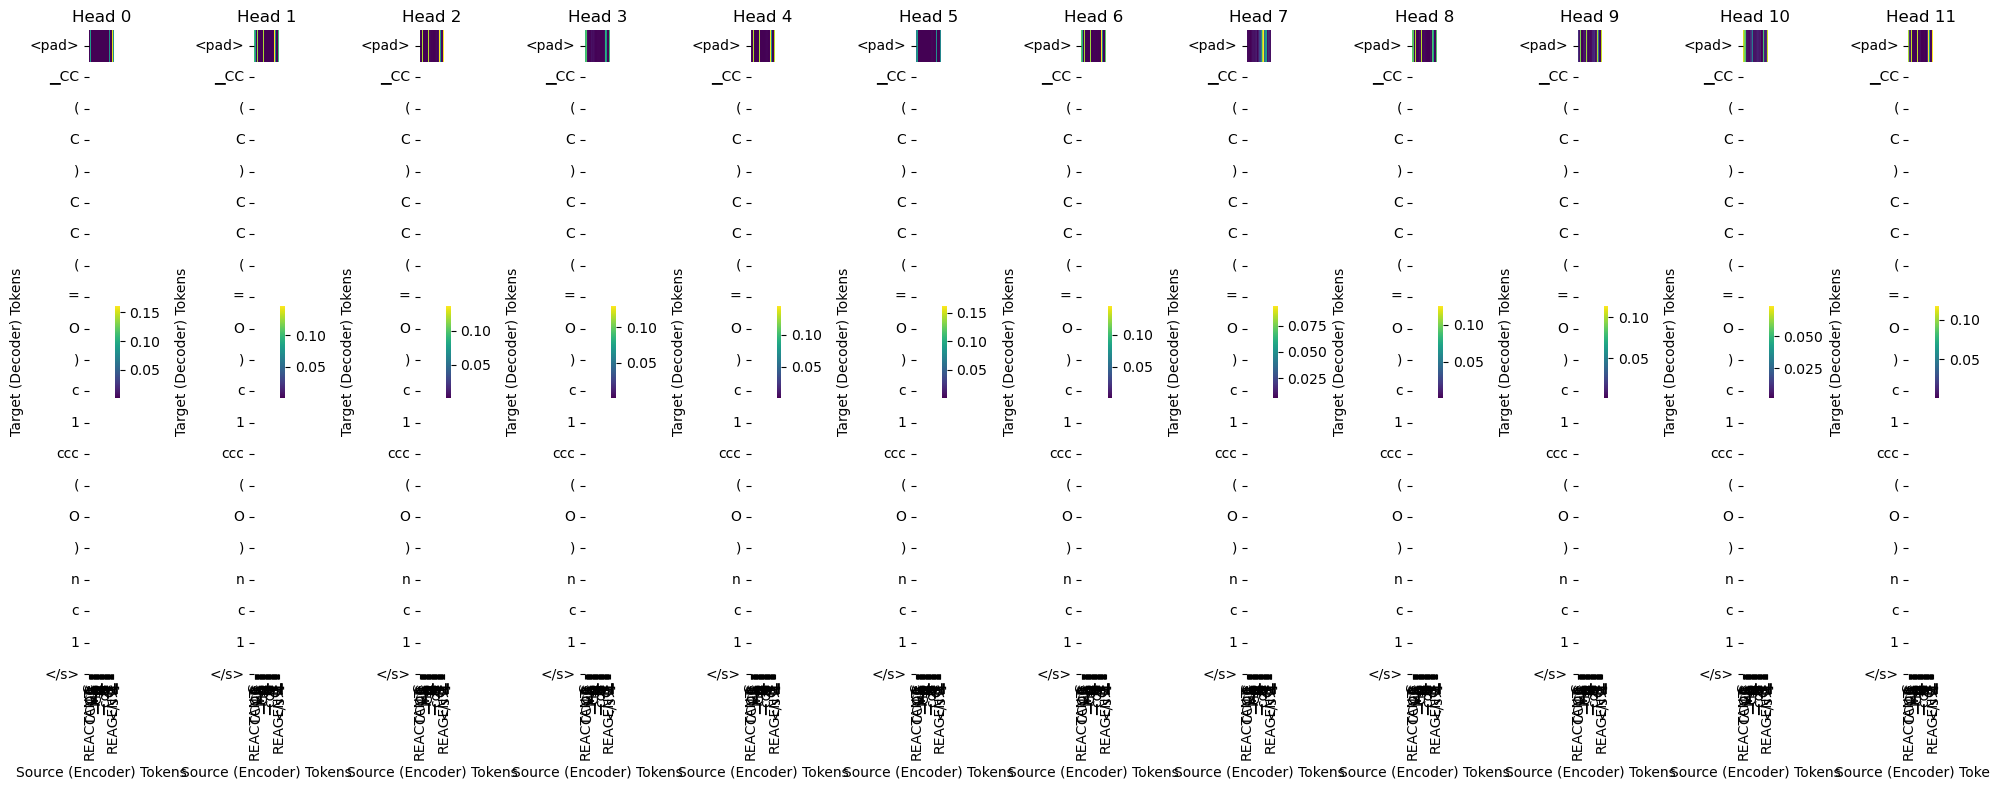

In [17]:
# last_layer shape: [1, num_heads, target_len, source_len]
# Replace with your actual input/output tokens
source_tokens = input_tokens
target_tokens = output_tokens

plot_attention_heads(last_layer, source_tokens, target_tokens)


# Visualize cross-attention over layers instead of heads

In [18]:
inp

{'input_ids': tensor([[266,  22,   7,  82,   7, 221,  26,   6,   3,   5,   3,  11, 241,  25,
          18,  10, 221,  32,  12,   6,   3,   5,   3,   6,  15,   9,   5,   4,
           7,  19,   6,   9,   5,  16,   4,   7, 221,  25,  11,  36,  25,  23,
          10, 267,   1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

Attention shape after squeeze: (20, 45)


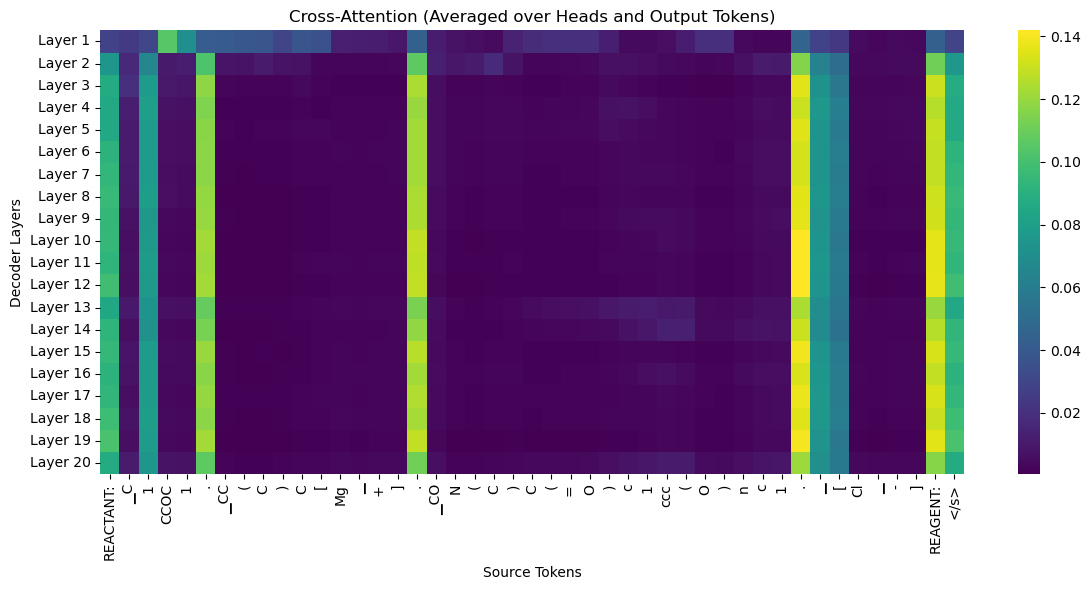

In [19]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assume `output` is from model.generate(..., output_attentions=True)
# cross_attentions = output["cross_attentions"]  # List: [num_layers] x (batch, num_heads, tgt_len, src_len)

# Get source tokens (input tokens)
input_ids = inp["input_ids"][0]
source_tokens = tokenizer.convert_ids_to_tokens(input_ids)

# Initialize attention map: [num_layers x src_len]
layerwise_attention = []

for layer_attention in cross_attentions:
    # layer_attention: shape (1, num_heads, tgt_len, src_len)
    attn = layer_attention[0]  # remove batch dim

    # Average over heads and output tokens
    avg_attn = attn.mean(dim=0).mean(dim=0)  # shape: [src_len]
    layerwise_attention.append(avg_attn)

# Stack into a 2D tensor: [num_layers x src_len]
layerwise_attention = torch.stack(layerwise_attention).cpu().numpy()

# If layerwise_attention has shape (num_layers, 1, src_len), squeeze the 1
if layerwise_attention.ndim == 3 and layerwise_attention.shape[1] == 1:
    layerwise_attention = layerwise_attention.squeeze(1)  # shape becomes (num_layers, src_len)

print(f"Attention shape after squeeze: {layerwise_attention.shape}")

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(layerwise_attention, xticklabels=source_tokens, yticklabels=[f'Layer {i+1}' for i in range(layerwise_attention.shape[0])], cmap="viridis")
plt.xlabel("Source Tokens")
plt.ylabel("Decoder Layers")
plt.title("Cross-Attention (Averaged over Heads and Output Tokens)")
plt.tight_layout()
plt.show()


From ChatGPT:
📝 What’s Happening:
- Squeeze step: After squeezing, the attention tensor will have shape (20, 45) — meaning 20 layers and 45 source tokens.

- Heatmap: Now you can plot the attention for each source token across all layers.

Expected Result:
- The X-axis will show your source tokens.

- The Y-axis will show the decoder layers.

- The color intensity will represent the cross-attention from each layer over the source tokens.

## Try again but without the useless characters

findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: 

Attention shape after squeeze: (20, 45)


findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans' not found.


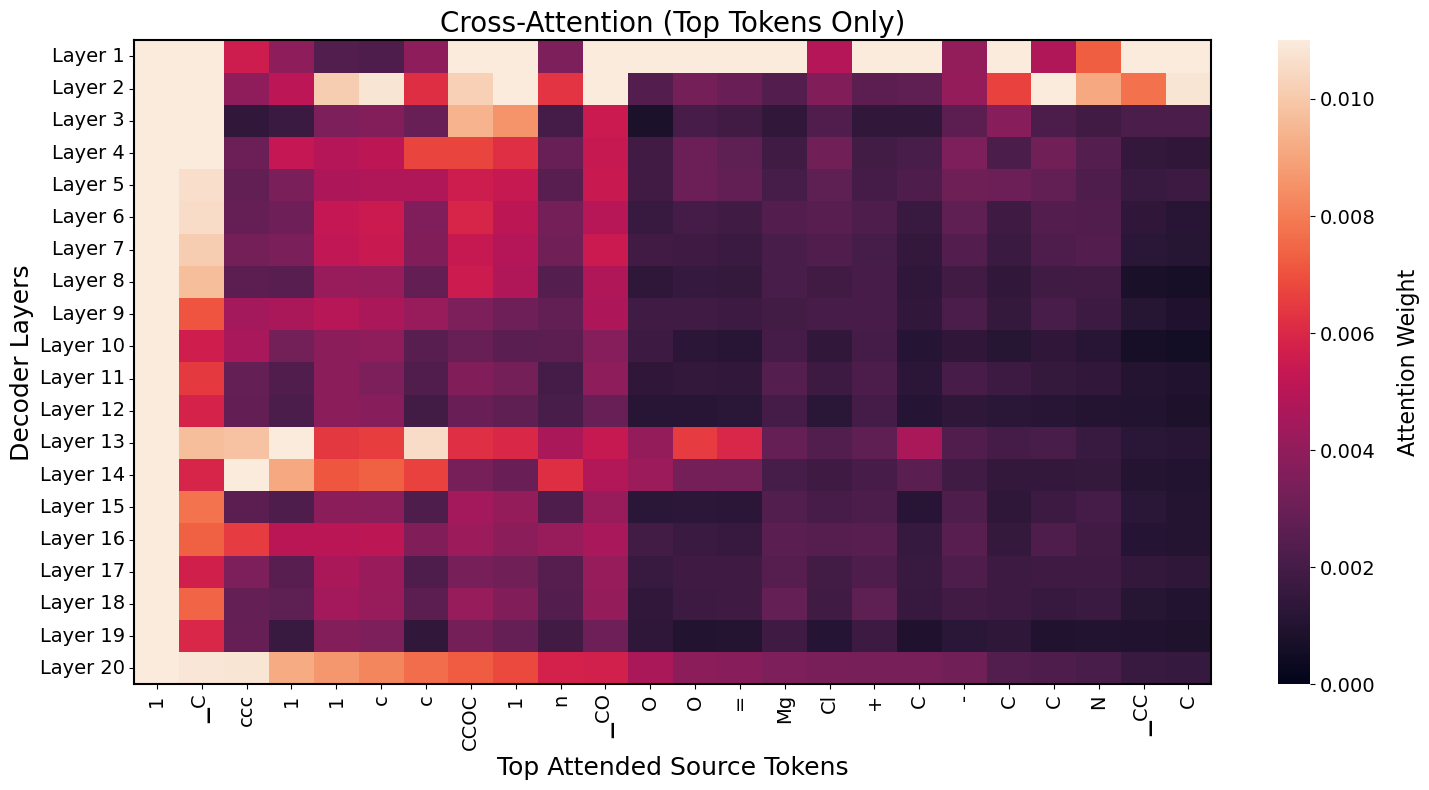

In [75]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Get input tokens
input_ids = inp["input_ids"][0]
source_tokens = tokenizer.convert_ids_to_tokens(input_ids)

# Step 2: Compute attention across layers
layerwise_attention = []
for layer_attention in cross_attentions:
    attn = layer_attention[0]  # shape: (num_heads, tgt_len=1, src_len)
    avg_attn = attn.mean(dim=0).mean(dim=0)  # shape: [src_len]
    layerwise_attention.append(avg_attn)

# Stack into [num_layers x src_len]
layerwise_attention = torch.stack(layerwise_attention).cpu().numpy()
if layerwise_attention.ndim == 3 and layerwise_attention.shape[1] == 1:
    layerwise_attention = layerwise_attention.squeeze(1)

print(f"Attention shape after squeeze: {layerwise_attention.shape}")

# Step 3: Identify indices of important tokens in source_tokens
filtered_indices = []
char_to_filter = ['REAGENT:', 'REACTANT:', '▁', '[', ']', '.', '(', ')', '</s>']

for idx, tok in enumerate(source_tokens):
    if tok not in char_to_filter:
        filtered_indices.append(idx)

# Optional: Sort indices by attention in last layer (layer -1)
top_n = 100
last_layer_attn = layerwise_attention[-1]
sorted_indices = sorted(filtered_indices, key=lambda i: last_layer_attn[i], reverse=True)[:top_n]

# Step 4: Subset attention and tokens for plotting
attention_subset = layerwise_attention[:, sorted_indices]
tokens_subset = [source_tokens[i] for i in sorted_indices]

# Step 5: Plot heatmap
plt.figure(figsize=(max(15, len(tokens_subset) * 0.3), 8))
ax = sns.heatmap(attention_subset,
            xticklabels=tokens_subset,
            yticklabels=[f'Layer {i+1}' for i in range(layerwise_attention.shape[0])],
            cmap="rocket",
            vmin=0.00, vmax=0.011,
            )

# Set the external border (spines) color to light gray
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
    

# Tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Attention Weight", fontsize=16, labelpad=15)

plt.xlabel("Top Attended Source Tokens", fontsize=18)
plt.ylabel("Decoder Layers", fontsize=18)
plt.title("Cross-Attention (Top Tokens Only)", fontsize=20)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
